In [2]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Read in initial data files

# updated the file path  
energy_df = pd.read_csv('../data/raw/energy_dataset.csv')
weather_df = pd.read_csv('../data/raw/weather_features.csv')

# Convert date/time to datetime format
energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)
weather_df['dt_iso'] = pd.to_datetime(weather_df['dt_iso'], utc=True)

# Extract date and hour for each dataframe
energy_df.insert(1, 'date', energy_df['time'].dt.date)
energy_df.insert(2, 'hour', energy_df['time'].dt.hour)

weather_df.insert(1, 'date', weather_df['dt_iso'].dt.date)
weather_df.insert(2, 'hour', weather_df['dt_iso'].dt.hour)

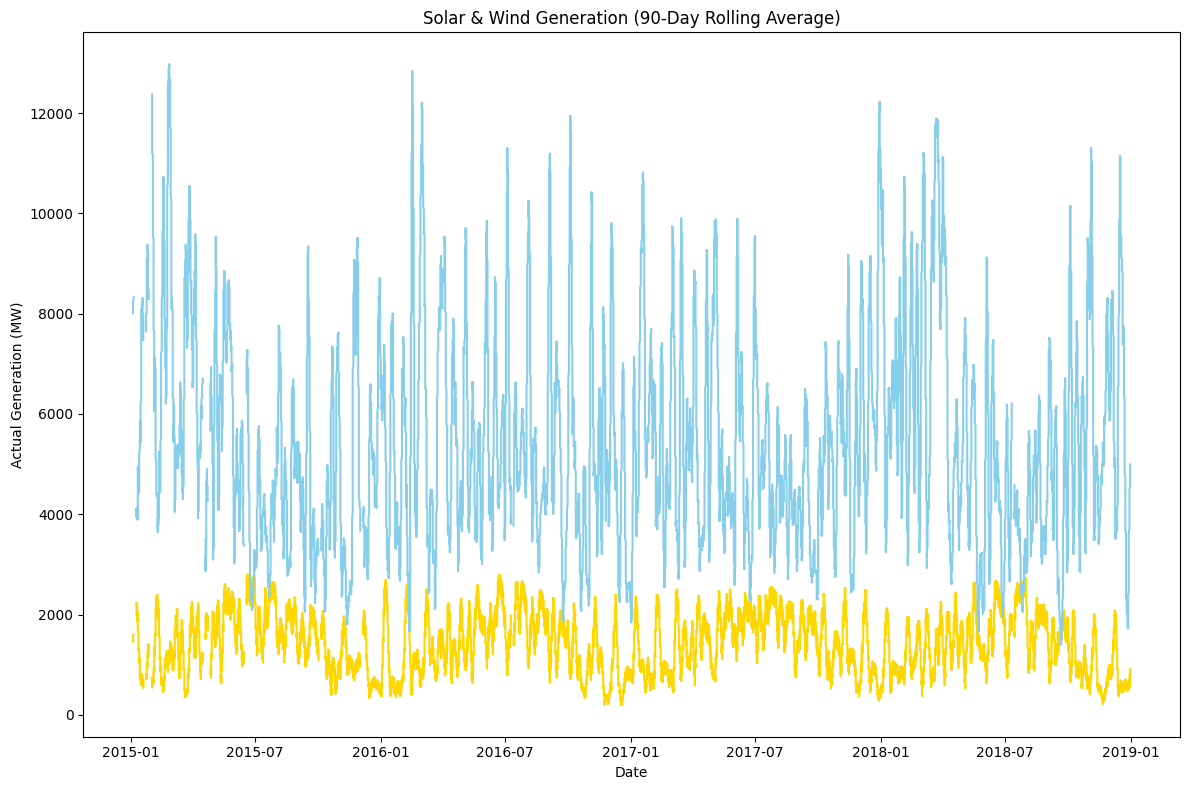

In [34]:
# Visualize initial renewable generation
# Create 90-day rolling average of generation
energy_df['solar_rolling'] = energy_df['generation solar'].rolling(window=90).mean()
energy_df['wind_rolling'] = energy_df['generation wind onshore'].rolling(window=90).mean()

# Define x-axis dataset
date = energy_df['date']

fig, ax = plt.subplots(figsize=(12,8))
# ax.plot(date, energy_df['generation solar'], color='gold', alpha=0.4)
ax.plot(date, energy_df['solar_rolling'], color='gold')
# ax.plot(date, energy_df['generation wind onshore'], color='skyblue', alpha=0.4)
ax.plot(date, energy_df['wind_rolling'], color='skyblue')

# Customize the plot
ax.set_xlabel('Date')
ax.set_ylabel('Actual Generation (MW)')
ax.set_title('Solar & Wind Generation (90-Day Rolling Average)')

plt.tight_layout()
plt.show()